<a href="https://colab.research.google.com/github/ElianaHeitner/CNN-and-MLP-project/blob/main/task_1_CNN_debugging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. CNN debugging

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import random

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

In [7]:
#Basic transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [8]:
#Download Dataset

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:02<00:00, 77.1MB/s]


In [9]:
# Creat DataLoaders

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

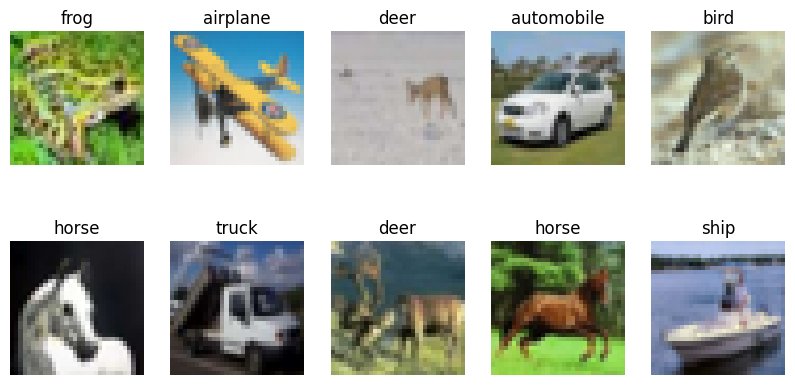

In [10]:

# CNN Sarter code

classes = train_dataset.classes

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):

    img = images[i] / 2 + 0.5
    img = img.permute(1, 2, 0)

    ax.imshow(img)
    ax.set_title(classes[labels[i]])
    ax.axis('off')

plt.show()



In [11]:
class InitialCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)

        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):

        x = torch.sigmoid(self.conv1(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv3(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv4(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)

        x = torch.sigmoid(self.fc1(x))
        x = self.fc2(x)

        return x

In [12]:
# Initialize Network

model = InitialCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [13]:
# Training function

def train(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    gradient_norms = {}

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        # Save gradient norms
        for name, param in model.named_parameters():

            if param.grad is not None:

                grad_norm = param.grad.norm().item()

                if name not in gradient_norms:
                    gradient_norms[name] = []

                gradient_norms[name].append(grad_norm)

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total

    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy, gradient_norms

In [14]:
# Testing function

def test(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total

    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy

In [31]:
# Reset InitialCNN before training

model = InitialCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [32]:
# Main training loop

num_epochs = 15

# Lists for saving loss values across epochs
train_losses = []
test_losses = []

# Lists for saving accuracy values across epochs
train_accs = []
test_accs = []

# Dictionary for saving gradient magnitudes across epochs
all_gradient_norms = {}

for epoch in range(num_epochs):

    # Train the model for one epoch
    train_loss, train_acc, grad_norms = train(
        model,
        train_loader
    )

    # Test the model after the epoch
    test_loss, test_acc = test(
        model,
        test_loader
    )

    # Save loss values for learning curves
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    # Save accuracy values for learning curves
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # Save average gradient magnitude for each layer
    for layer_name, values in grad_norms.items():

        if layer_name not in all_gradient_norms:
            all_gradient_norms[layer_name] = []

        all_gradient_norms[layer_name].append(np.mean(values))

    # Print results for this epoch
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print("-" * 40)


# Prepare epoch numbers for plots
epochs = range(1, num_epochs + 1)


# Check that values were saved correctly
print("Saved values check:")
print("Number of train losses:", len(train_losses))
print("Number of test losses:", len(test_losses))
print("Number of train accuracies:", len(train_accs))
print("Number of test accuracies:", len(test_accs))

print("Gradient layers:")
print(all_gradient_norms.keys())

Epoch 1/15
Train Loss: 2.1298
Train Accuracy: 19.36%
Test Loss: 1.9167
Test Accuracy: 28.27%
----------------------------------------
Epoch 2/15
Train Loss: 1.8480
Train Accuracy: 30.66%
Test Loss: 1.7294
Test Accuracy: 34.78%
----------------------------------------
Epoch 3/15
Train Loss: 1.6817
Train Accuracy: 37.81%
Test Loss: 1.6519
Test Accuracy: 37.20%
----------------------------------------
Epoch 4/15
Train Loss: 1.5616
Train Accuracy: 42.76%
Test Loss: 1.4878
Test Accuracy: 45.38%
----------------------------------------
Epoch 5/15
Train Loss: 1.4682
Train Accuracy: 46.60%
Test Loss: 1.4379
Test Accuracy: 47.58%
----------------------------------------
Epoch 6/15
Train Loss: 1.3923
Train Accuracy: 49.40%
Test Loss: 1.3804
Test Accuracy: 49.37%
----------------------------------------
Epoch 7/15
Train Loss: 1.3391
Train Accuracy: 51.39%
Test Loss: 1.3206
Test Accuracy: 52.13%
----------------------------------------
Epoch 8/15
Train Loss: 1.2809
Train Accuracy: 53.53%
Test Loss

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import os

save_dir = "/content/drive/MyDrive/CNN_MLP_project"
os.makedirs(save_dir, exist_ok=True)

torch.save(model.state_dict(), save_dir + "/initialcnn_trained_weights.pth")

print("Trained InitialCNN weights saved.")

Trained InitialCNN weights saved.


In [35]:
# Save InitialCNN results manually from the printed output

num_epochs = 15
epochs = range(1, num_epochs + 1)

# Loss values from InitialCNN
train_losses = [
    2.1635, 1.8812, 1.6809, 1.5351, 1.4439,
    1.3649, 1.3103, 1.2487, 1.1955, 1.1458,
    1.0912, 1.0470, 1.0007, 0.9548, 0.9071
]

test_losses = [
    1.9574, 1.7394, 1.5795, 1.5141, 1.4035,
    1.3387, 1.2735, 1.2406, 1.1968, 1.1613,
    1.1254, 1.0881, 1.0871, 1.0542, 1.0277
]

# Accuracy values from InitialCNN
train_accs = [
    17.73, 30.67, 38.76, 44.22, 47.68,
    50.35, 52.64, 54.99, 56.85, 58.66,
    60.87, 62.34, 64.12, 66.13, 67.61
]

test_accs = [
    26.71, 36.44, 42.59, 45.19, 49.44,
    51.72, 53.44, 55.19, 57.10, 58.08,
    59.43, 60.73, 61.38, 62.47, 63.89
]

# Save them under InitialCNN-specific names
initial_train_losses = train_losses.copy()
initial_test_losses = test_losses.copy()

initial_train_accs = train_accs.copy()
initial_test_accs = test_accs.copy()

# Save final values
initial_final_train_loss = initial_train_losses[-1]
initial_final_test_loss = initial_test_losses[-1]

initial_final_train_acc = initial_train_accs[-1]
initial_final_test_acc = initial_test_accs[-1]

# Save gradient values if all_gradient_norms still exists in memory
try:
    initial_gradient_norms = {
        layer_name: values.copy()
        for layer_name, values in all_gradient_norms.items()
    }
    print("Gradient values were saved successfully.")
except NameError:
    initial_gradient_norms = None
    print("Gradient values were not found in memory. Loss and accuracy were saved, but gradients cannot be reconstructed from printed keys only.")

# Check saved values
print("InitialCNN results saved.")
print(f"Final Training Loss: {initial_final_train_loss:.4f}")
print(f"Final Training Accuracy: {initial_final_train_acc:.2f}%")
print(f"Final Test Loss: {initial_final_test_loss:.4f}")
print(f"Final Test Accuracy: {initial_final_test_acc:.2f}%")

Gradient values were saved successfully.
InitialCNN results saved.
Final Training Loss: 0.9071
Final Training Accuracy: 67.61%
Final Test Loss: 1.0277
Final Test Accuracy: 63.89%


In [36]:
print("Final Results for InitialCNN")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Training Accuracy: {train_accs[-1]:.2f}%")
print(f"Final Test Accuracy: {test_accs[-1]:.2f}%")

Final Results for InitialCNN
Final Training Loss: 0.9071
Final Training Accuracy: 67.61%
Final Test Accuracy: 63.89%


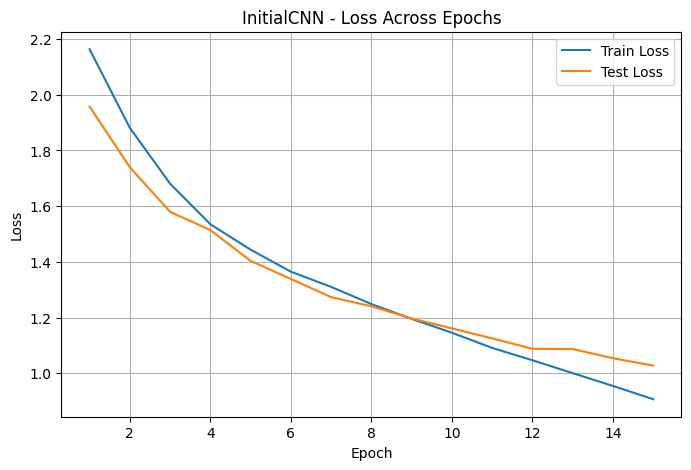

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("InitialCNN - Loss Across Epochs")
plt.legend()
plt.grid(True)

plt.savefig("plot 1:initialcnn_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

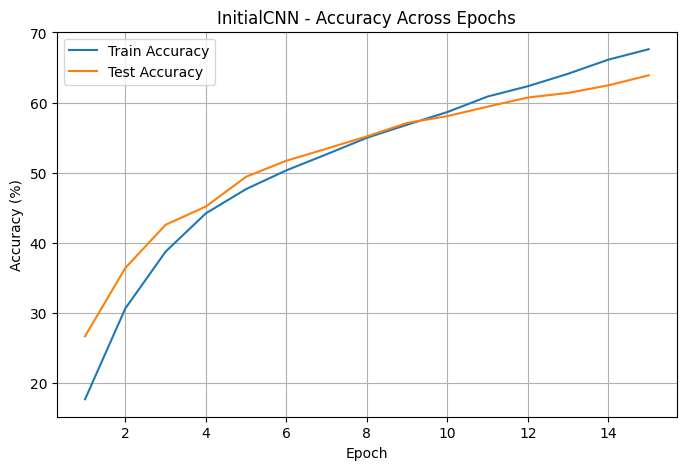

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, test_accs, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("InitialCNN - Accuracy Across Epochs")
plt.legend()
plt.grid(True)

plt.savefig("plot 2: initialcnn_accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
print(all_gradient_norms.keys())

dict_keys(['conv1.weight', 'conv1.bias', 'conv2.weight', 'conv2.bias', 'conv3.weight', 'conv3.bias', 'conv4.weight', 'conv4.bias', 'fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias'])


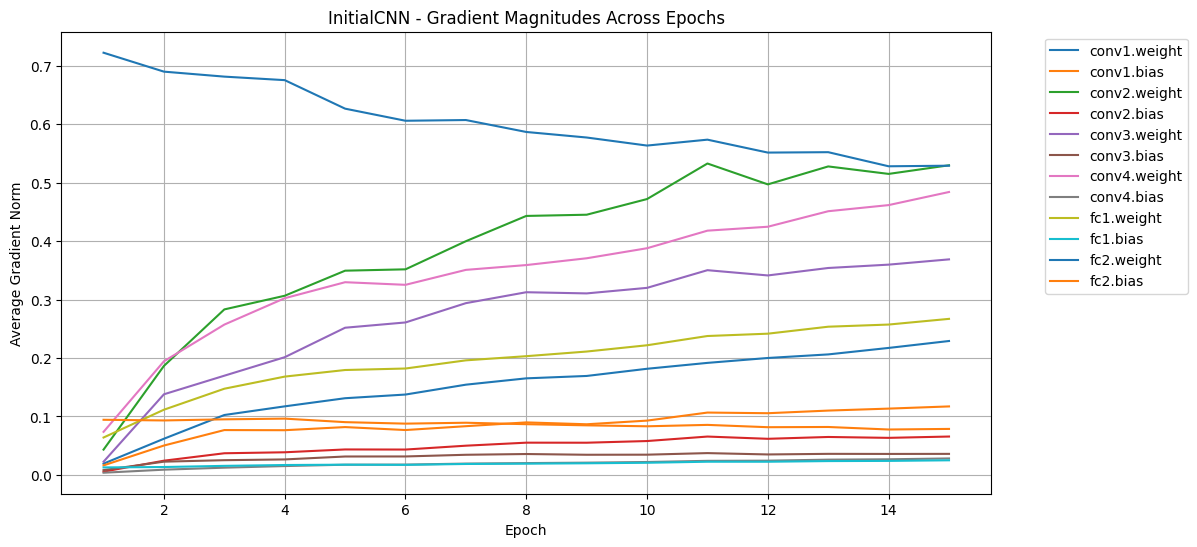

In [40]:
# Gradient magnitudes across epochs

plt.figure(figsize=(12, 6))

for layer_name, values in all_gradient_norms.items():
    plt.plot(epochs, values, label=layer_name)

plt.xlabel("Epoch")
plt.ylabel("Average Gradient Norm")
plt.title("InitialCNN - Gradient Magnitudes Across Epochs")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

plt.savefig("plot 3:initialcnn_gradient_magnitudes.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
# Save InitialCNN results before training the improved model

initial_train_losses = train_losses.copy()
initial_test_losses = test_losses.copy()

initial_train_accs = train_accs.copy()
initial_test_accs = test_accs.copy()

initial_gradient_norms = {
    layer_name: values.copy()
    for layer_name, values in all_gradient_norms.items()
}

In [42]:
# Improved CNN with one additional Batch Normalization layer

class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)   # One additional layer

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)

        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.sigmoid(x)
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv3(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv4(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)

        x = torch.sigmoid(self.fc1(x))
        x = self.fc2(x)

        return x

In [43]:
# Train ImprovedCNN

improved_model = ImprovedCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    improved_model.parameters(),
    lr=0.001
)

num_epochs = 15

improved_train_losses = []
improved_test_losses = []

improved_train_accs = []
improved_test_accs = []

improved_gradient_norms = {}

for epoch in range(num_epochs):

    train_loss, train_acc, grad_norms = train(
        improved_model,
        train_loader
    )

    test_loss, test_acc = test(
        improved_model,
        test_loader
    )

    improved_train_losses.append(train_loss)
    improved_test_losses.append(test_loss)

    improved_train_accs.append(train_acc)
    improved_test_accs.append(test_acc)

    for layer_name, values in grad_norms.items():

        if layer_name not in improved_gradient_norms:
            improved_gradient_norms[layer_name] = []

        improved_gradient_norms[layer_name].append(np.mean(values))

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print("-" * 40)

Epoch 1/15
Train Loss: 2.1732
Train Accuracy: 17.15%
Test Loss: 1.9596
Test Accuracy: 26.92%
----------------------------------------
Epoch 2/15
Train Loss: 1.8682
Train Accuracy: 31.13%
Test Loss: 1.7222
Test Accuracy: 36.99%
----------------------------------------
Epoch 3/15
Train Loss: 1.6387
Train Accuracy: 39.96%
Test Loss: 1.5279
Test Accuracy: 43.24%
----------------------------------------
Epoch 4/15
Train Loss: 1.4929
Train Accuracy: 45.18%
Test Loss: 1.4393
Test Accuracy: 46.82%
----------------------------------------
Epoch 5/15
Train Loss: 1.4025
Train Accuracy: 48.97%
Test Loss: 1.3857
Test Accuracy: 48.79%
----------------------------------------
Epoch 6/15
Train Loss: 1.3268
Train Accuracy: 51.76%
Test Loss: 1.3076
Test Accuracy: 52.11%
----------------------------------------
Epoch 7/15
Train Loss: 1.2556
Train Accuracy: 54.48%
Test Loss: 1.2272
Test Accuracy: 55.27%
----------------------------------------
Epoch 8/15
Train Loss: 1.1884
Train Accuracy: 56.96%
Test Loss

In [44]:
# Save InitialCNN results for comparison

initial_train_losses = train_losses.copy()
initial_test_losses = test_losses.copy()

initial_train_accs = train_accs.copy()
initial_test_accs = test_accs.copy()

initial_gradient_norms = {
    layer_name: values.copy()
    for layer_name, values in all_gradient_norms.items()
}

In [45]:
# Compare InitialCNN and ImprovedCNN

print("Comparison: InitialCNN vs ImprovedCNN")
print("-" * 50)

print(f"InitialCNN Final Training Loss: {initial_train_losses[-1]:.4f}")
print(f"ImprovedCNN Final Training Loss: {improved_train_losses[-1]:.4f}")

print("-" * 50)

print(f"InitialCNN Final Training Accuracy: {initial_train_accs[-1]:.2f}%")
print(f"ImprovedCNN Final Training Accuracy: {improved_train_accs[-1]:.2f}%")

print("-" * 50)

print(f"InitialCNN Final Test Accuracy: {initial_test_accs[-1]:.2f}%")
print(f"ImprovedCNN Final Test Accuracy: {improved_test_accs[-1]:.2f}%")

Comparison: InitialCNN vs ImprovedCNN
--------------------------------------------------
InitialCNN Final Training Loss: 0.9071
ImprovedCNN Final Training Loss: 0.8280
--------------------------------------------------
InitialCNN Final Training Accuracy: 67.61%
ImprovedCNN Final Training Accuracy: 70.88%
--------------------------------------------------
InitialCNN Final Test Accuracy: 63.89%
ImprovedCNN Final Test Accuracy: 67.00%


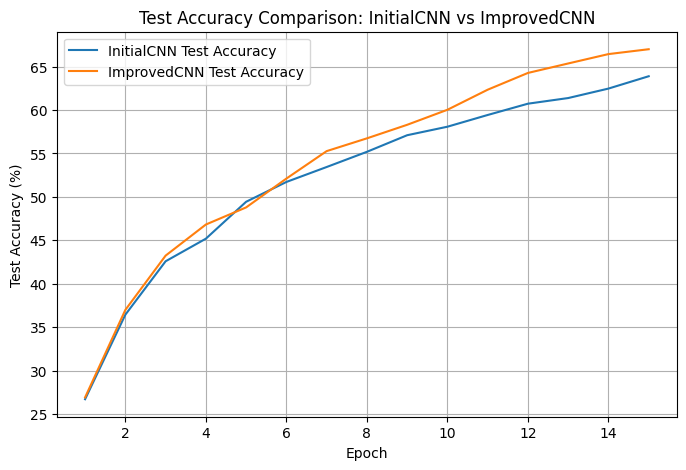

In [46]:
# Compare test accuracy across epochs

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, initial_test_accs, label="InitialCNN Test Accuracy")
plt.plot(epochs, improved_test_accs, label="ImprovedCNN Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Comparison: InitialCNN vs ImprovedCNN")
plt.legend()
plt.grid(True)

plt.savefig("plot 4: initial_vs_improved_test_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()